first run load_rand_forest.py

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../in_top10_features_nl.csv', index_col=0)
df = df.reset_index()
df[["simulated", "seed", "freq", "size", "noise", "dataset"]] = df['index'].str.split('_', expand=True)

df = df.drop(columns=["simulated", "dataset"])

for col in ["seed", "freq", "size", "noise"]:
    df[col] = df[col].str.replace(col, "").astype(int)

df.set_index('index', inplace=True)
df

,GPK,PKA,KAL,ALM,LMV,seed,freq,size,noise
index,,,,,,,,,
simulated_seed3_freq010_size1000_noise5_dataset,0.092143,NaN,NaN,NaN,NaN,3,10,1000,5
simulated_seed3_freq010_size1000_noise25_dataset,0.106599,NaN,NaN,NaN,NaN,3,10,1000,25
simulated_seed3_freq010_size1000_noise50_dataset,0.123907,NaN,NaN,NaN,NaN,3,10,1000,50
simulated_seed3_freq010_size1000_noise60_dataset,0.134150,NaN,NaN,NaN,NaN,3,10,1000,60
simulated_seed3_freq010_size1000_noise70_dataset,0.105953,NaN,NaN,NaN,NaN,3,10,1000,70
...,...,...,...,...,...,...,...,...,...
simulated_seed7_freq050_size150_noise25_dataset,0.032208,0.030389,0.037696,0.037418,0.023273,7,50,150,25
simulated_seed7_freq050_size150_noise50_dataset,0.043429,0.035056,0.046071,0.046693,0.030540,7,50,150,50
simulated_seed7_freq050_size150_noise60_dataset,0.046341,0.042548,0.050282,0.039968,0.044593,7,50,150,60


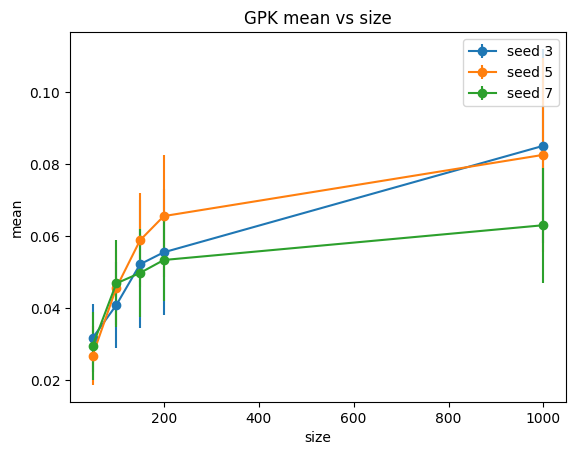

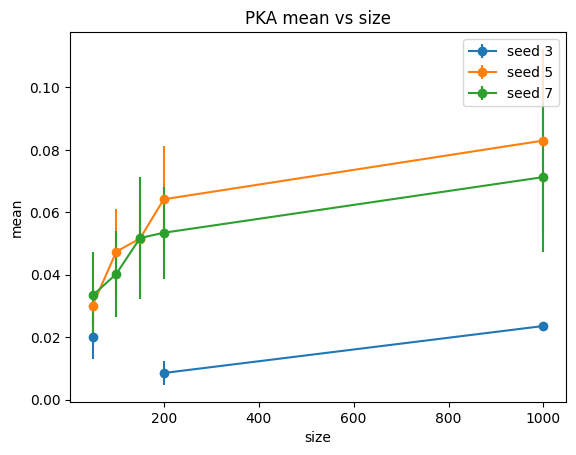

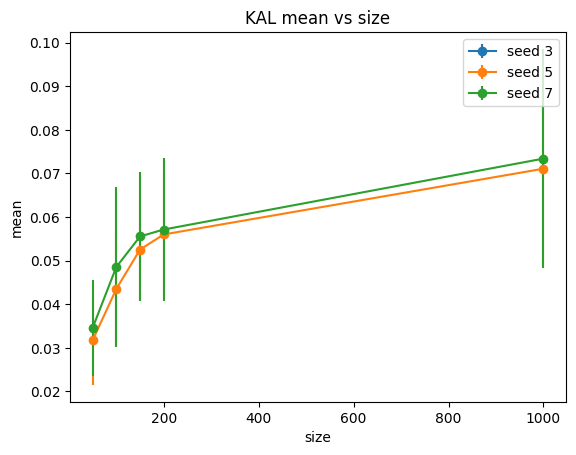

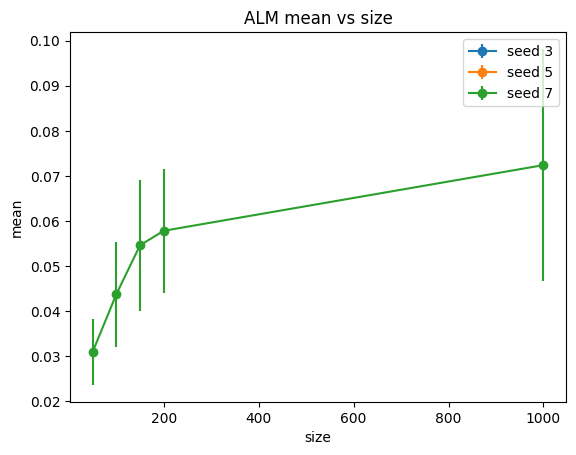

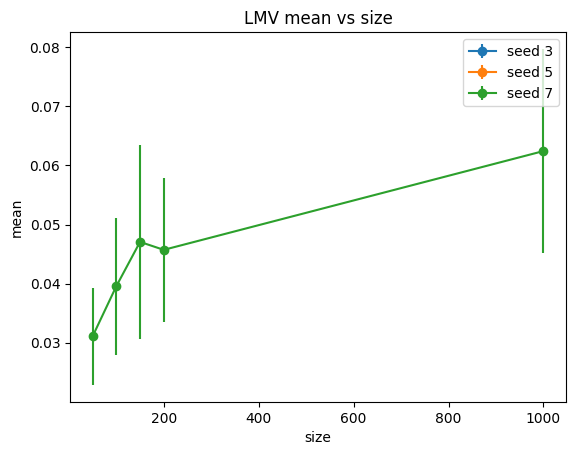

In [2]:
for kmer in ['GPK', 'PKA', 'KAL', 'ALM', 'LMV']:

    summary = df.groupby(['size', 'seed']).agg(
        missing=(kmer, lambda x: x.isna().sum()),
        mean=(kmer, 'mean'),
        std=(kmer, 'std')
    ).reset_index()

    for seed, g in summary.groupby("seed"):
        g = g.sort_values("size")
        plt.errorbar(
            g["size"],
            g["mean"],
            yerr=g["std"],
            marker="o",
            label=f"seed {seed}"
        )

    plt.xlabel("size")
    plt.ylabel("mean")
    plt.title(f"{kmer} mean vs size")
    plt.legend()
    plt.show()

/tmp/ipykernel_702194/836057271.py:15: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.lineplot(


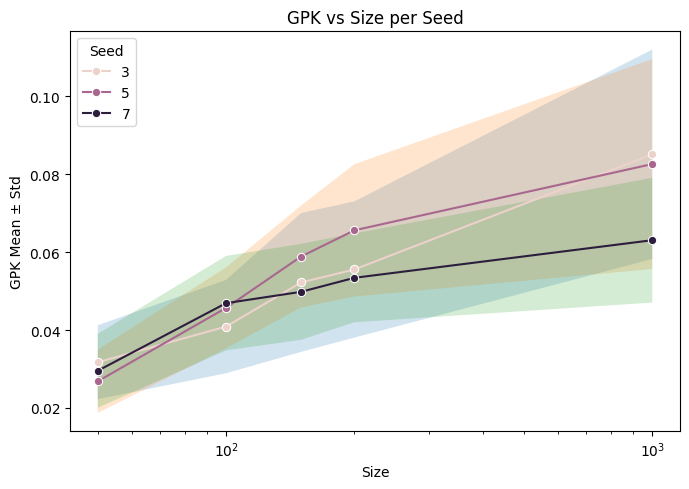

/tmp/ipykernel_702194/836057271.py:15: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.lineplot(


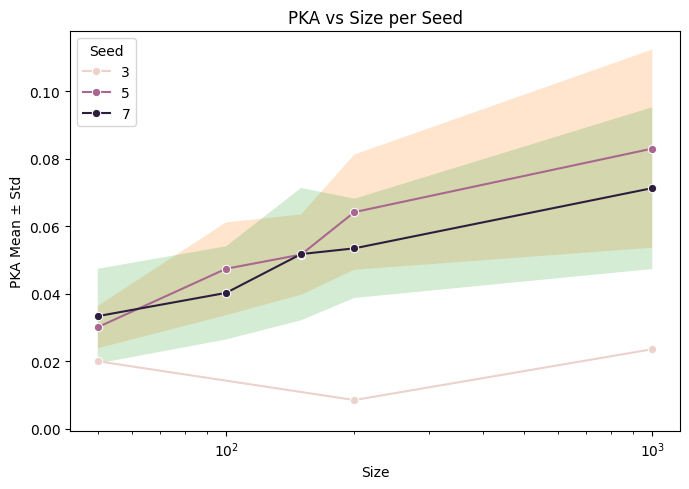

/tmp/ipykernel_702194/836057271.py:15: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.lineplot(


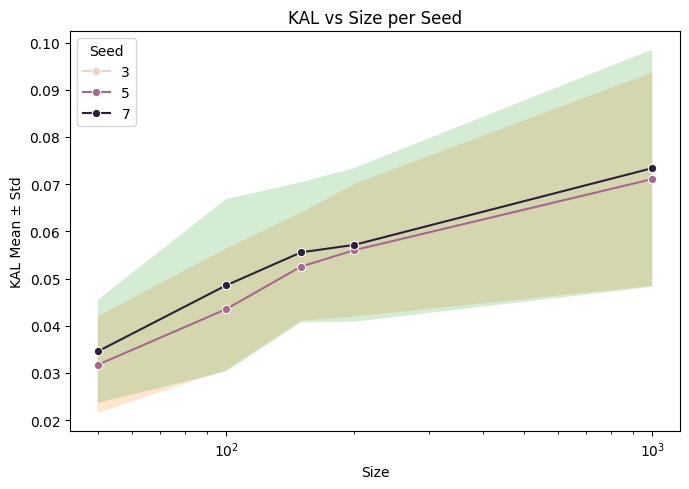

/tmp/ipykernel_702194/836057271.py:15: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.lineplot(


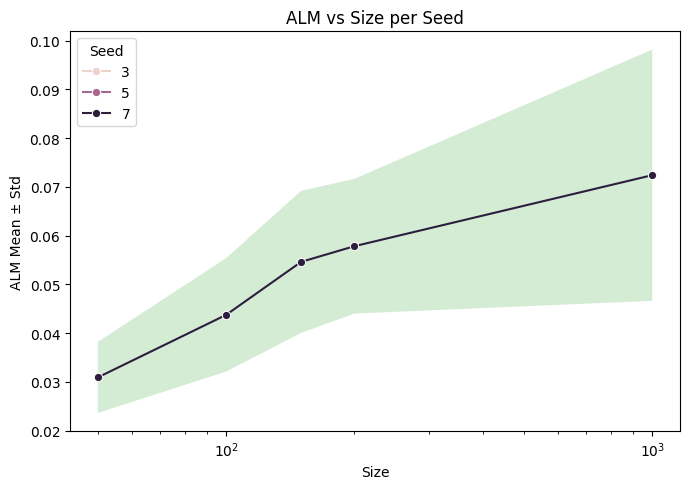

/tmp/ipykernel_702194/836057271.py:15: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.lineplot(


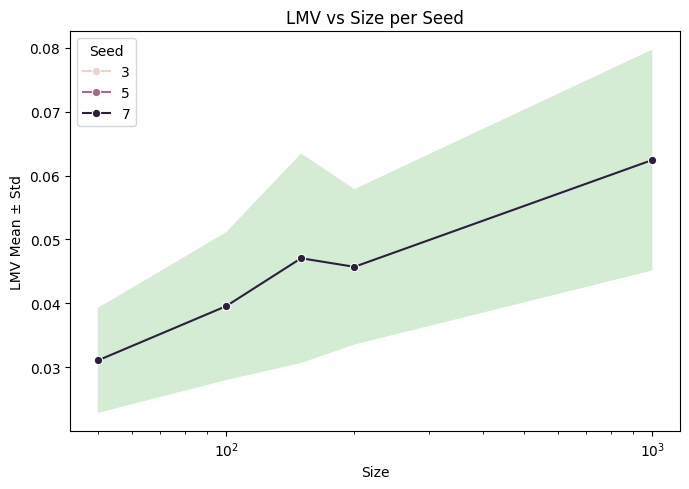

In [3]:
for kmer in ['GPK', 'PKA', 'KAL', 'ALM', 'LMV']:

    summary = df.groupby(['size', 'seed']).agg(
        missing=(kmer, lambda x: x.isna().sum()),
        mean=(kmer, 'mean'),
        std=(kmer, 'std')
    ).reset_index()


    # Suppose summary_df has GPK_mean and GPK_std per size and seed
    # summary_df = df.groupby(['size','seed']).agg(...).reset_index()

    plt.figure(figsize=(7,5))

    sns.lineplot(
        data=summary.sort_values("size"),   # automatic sorting by size
        x="size",
        y="mean",
        hue="seed",
        marker="o",
        err_style="band",                      # confidence band (uses std if available)
        ci=None                                # or specify confidence interval
    )

    # Add shaded error manually if you prefer
    for seed, g in summary.groupby("seed"):
        plt.fill_between(
            g["size"],
            g["mean"] - g["std"],
            g["mean"] + g["std"],
            alpha=0.2
        )

    plt.xscale("log")          # log-scale for size
    plt.xlabel("Size")
    plt.ylabel(f"{kmer} Mean ± Std")
    plt.title(f"{kmer} vs Size per Seed")
    plt.legend(title="Seed")
    plt.tight_layout()
    plt.show()

In [4]:
metrics_df = pd.read_csv('../metrics_full_nl.csv', index_col=0)
metrics_df = metrics_df.reset_index()
metrics_df[["simulated", "seed", "freq", "size", "noise", "dataset"]] = metrics_df['index'].str.split('_', expand=True)

metrics_df = metrics_df.drop(columns=["simulated", "dataset"])

for col in ["seed", "freq", "size", "noise"]:
    metrics_df[col] = metrics_df[col].str.replace(col, "").astype(int)

metrics_df.set_index('index', inplace=True)
metrics_df

,ACC,Balanced_ACC,Precision,Recall,AUROC,AUPRC,MCC,seed,freq,size,noise
index,,,,,,,,,,,
simulated_seed3_freq010_size1000_noise5_dataset,1.000000,1.000000,1.000000,1.000000,1.00000,1.000000,1.000000,3,10,1000,5
simulated_seed3_freq010_size1000_noise25_dataset,0.990000,0.990000,0.990000,0.990000,0.99990,0.999901,0.980000,3,10,1000,25
simulated_seed3_freq010_size1000_noise50_dataset,0.950000,0.950000,0.950000,0.950000,0.98435,0.981978,0.900000,3,10,1000,50
simulated_seed3_freq010_size1000_noise60_dataset,0.870000,0.870000,0.855769,0.890000,0.93670,0.921195,0.740593,3,10,1000,60
simulated_seed3_freq010_size1000_noise70_dataset,0.775000,0.775000,0.795699,0.740000,0.84780,0.821557,0.551352,3,10,1000,70
...,...,...,...,...,...,...,...,...,...,...,...
simulated_seed7_freq050_size150_noise25_dataset,1.000000,1.000000,1.000000,1.000000,1.00000,1.000000,1.000000,7,50,150,25
simulated_seed7_freq050_size150_noise50_dataset,1.000000,1.000000,1.000000,1.000000,1.00000,1.000000,1.000000,7,50,150,50
simulated_seed7_freq050_size150_noise60_dataset,1.000000,1.000000,1.000000,1.000000,1.00000,1.000000,1.000000,7,50,150,60


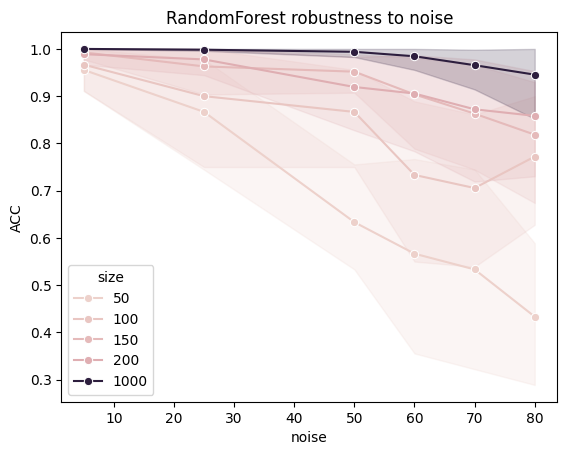

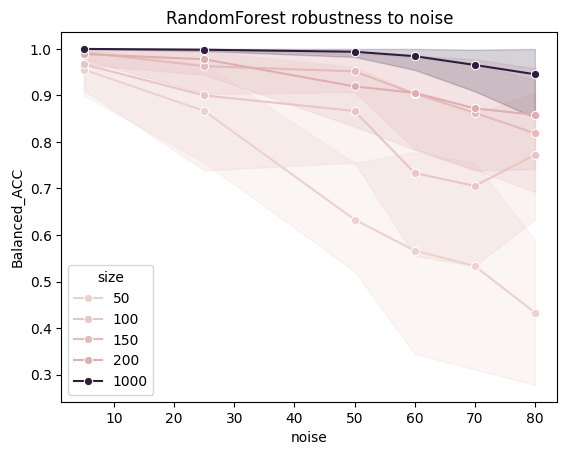

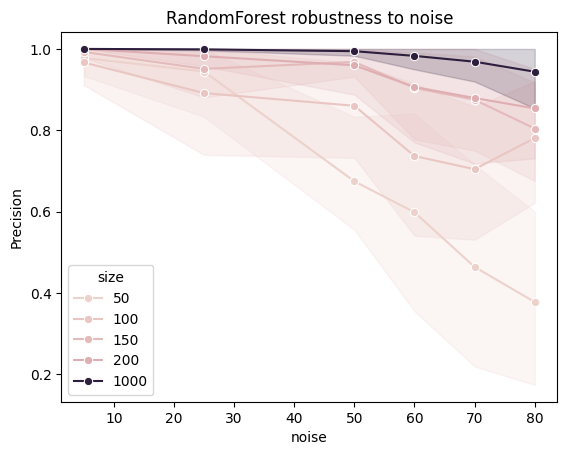

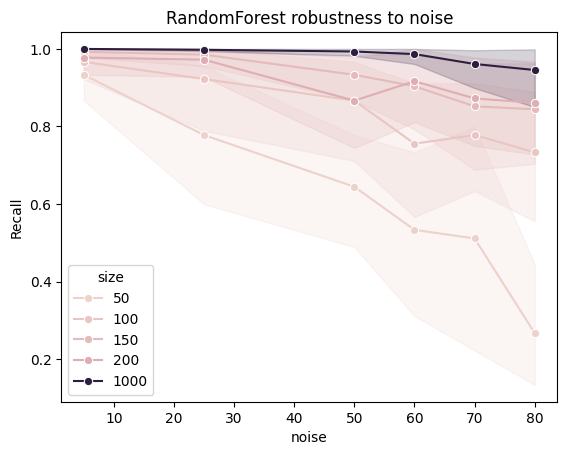

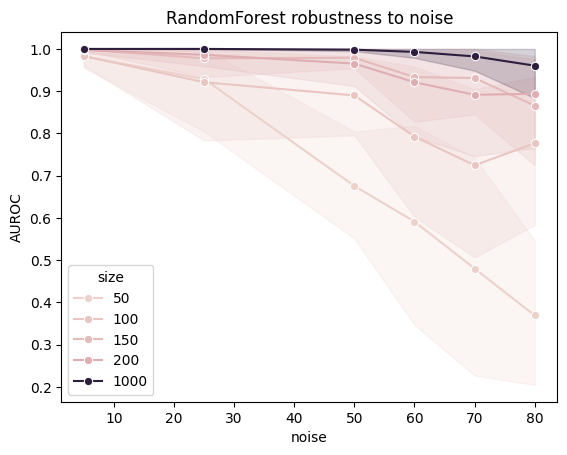

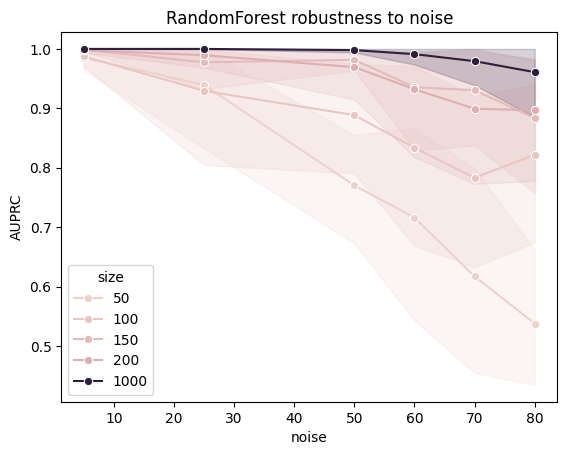

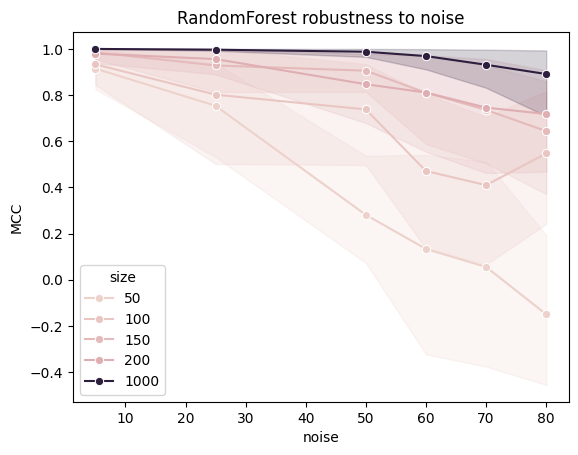

In [5]:
for metric in ['ACC', 'Balanced_ACC', 'Precision', 'Recall', 'AUROC', 'AUPRC', 'MCC']:
    sns.lineplot(
        data=metrics_df,
        x="noise",
        y=metric,
        hue="size",
        marker="o"
    )

    plt.title("RandomForest robustness to noise")
    plt.show()

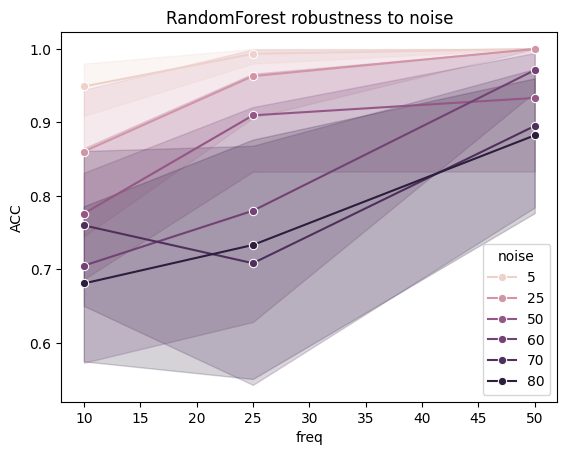

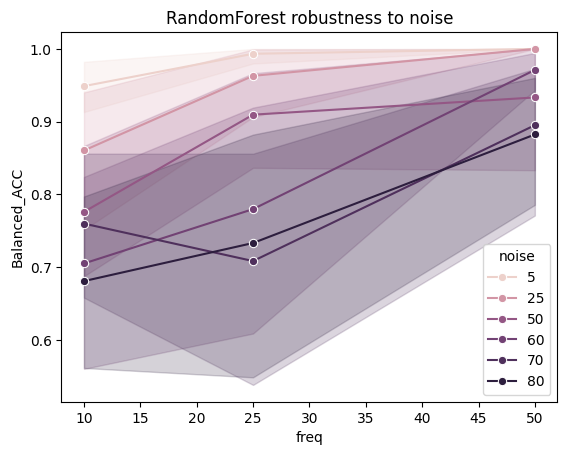

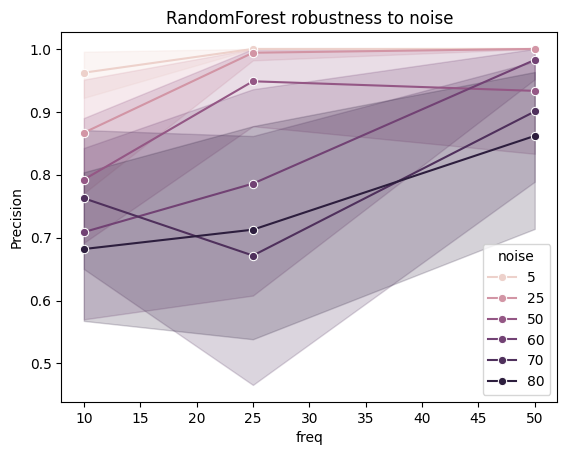

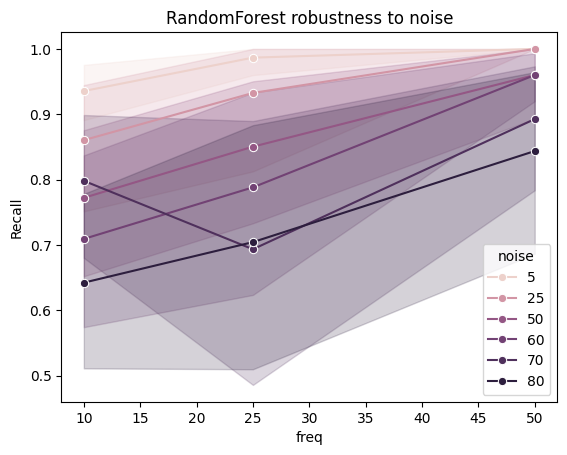

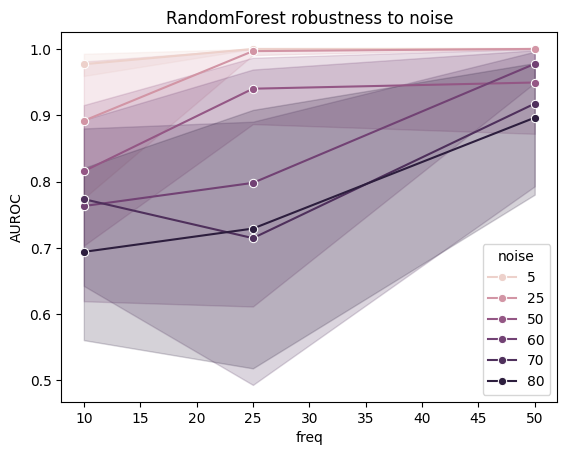

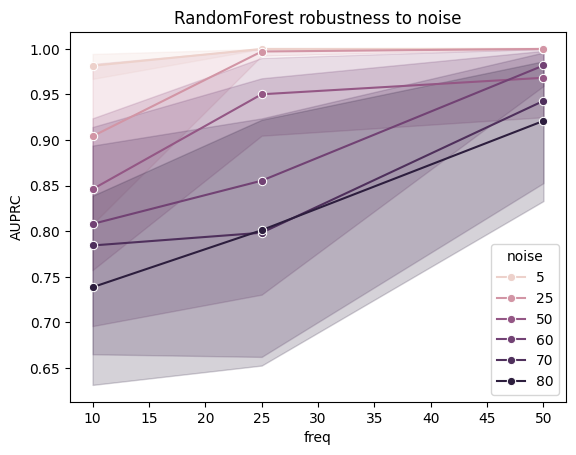

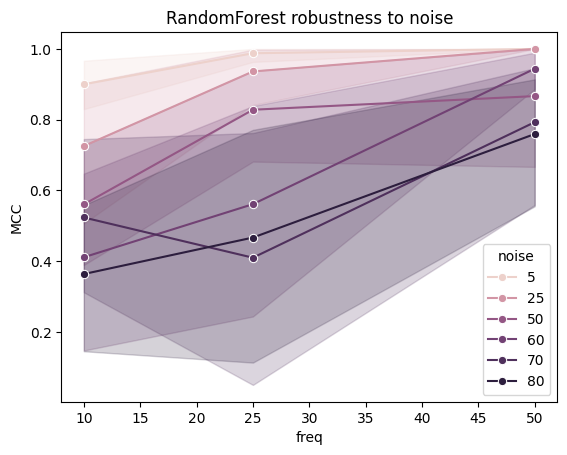

In [6]:
for metric in ['ACC', 'Balanced_ACC', 'Precision', 'Recall', 'AUROC', 'AUPRC', 'MCC']:
    sns.lineplot(
    data=metrics_df,
    x="freq",
    y=metric,
    hue="noise",
    marker="o"
    )

    plt.title("RandomForest robustness to noise")
    plt.show()

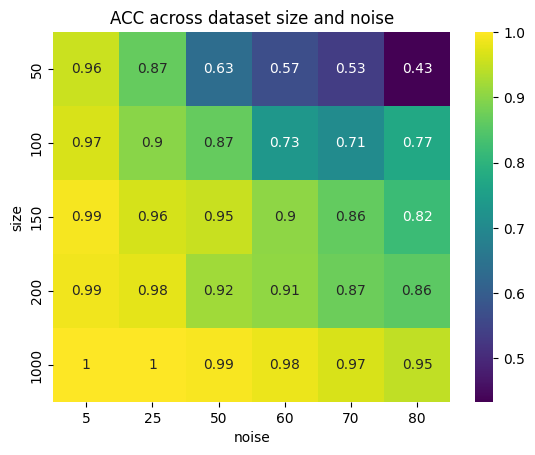

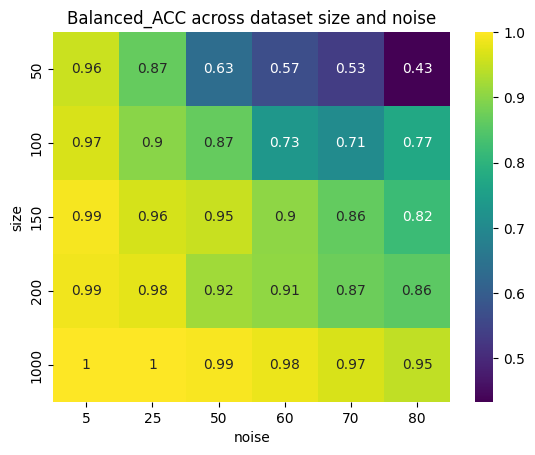

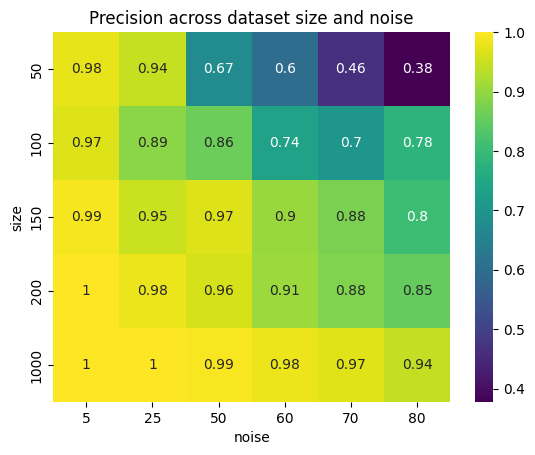

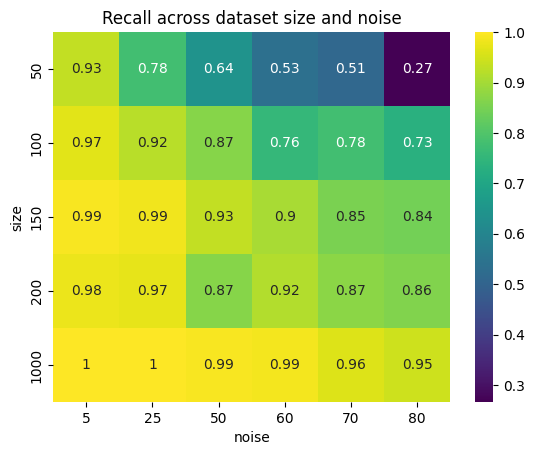

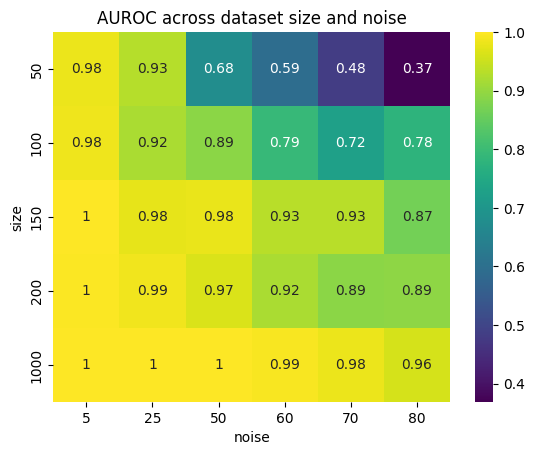

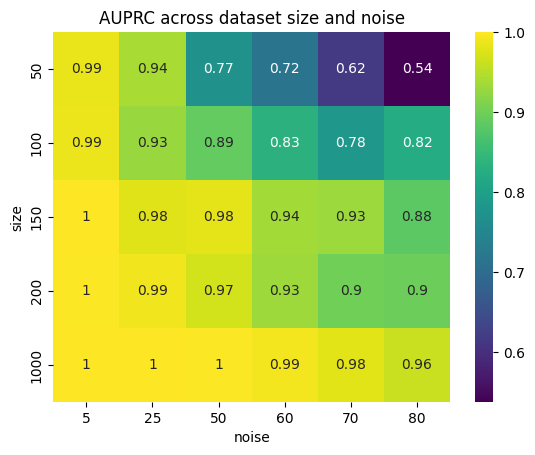

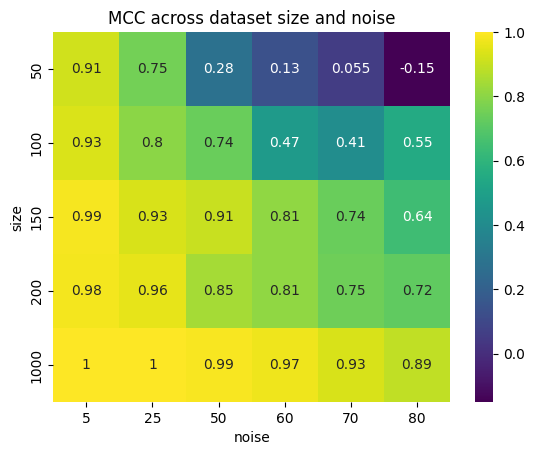

In [7]:
for metric in ['ACC', 'Balanced_ACC', 'Precision', 'Recall', 'AUROC', 'AUPRC', 'MCC']:
    pivot = metrics_df.pivot_table(
        values=metric,
        index="size",
        columns="noise"
    )

    sns.heatmap(pivot, annot=True, cmap="viridis")
    plt.title(f"{metric} across dataset size and noise")
    plt.show()

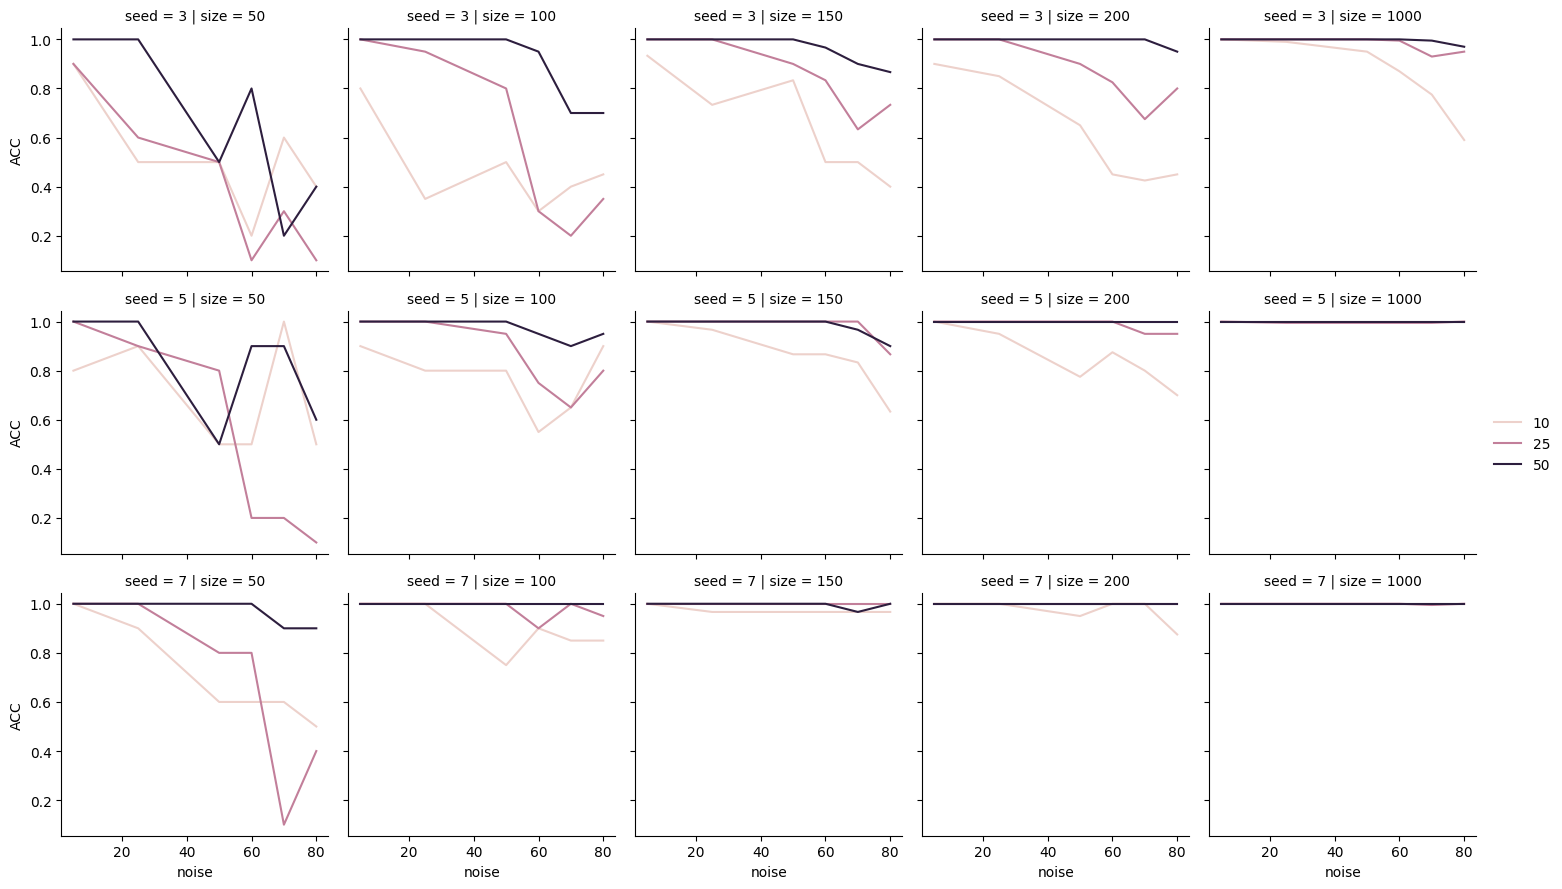

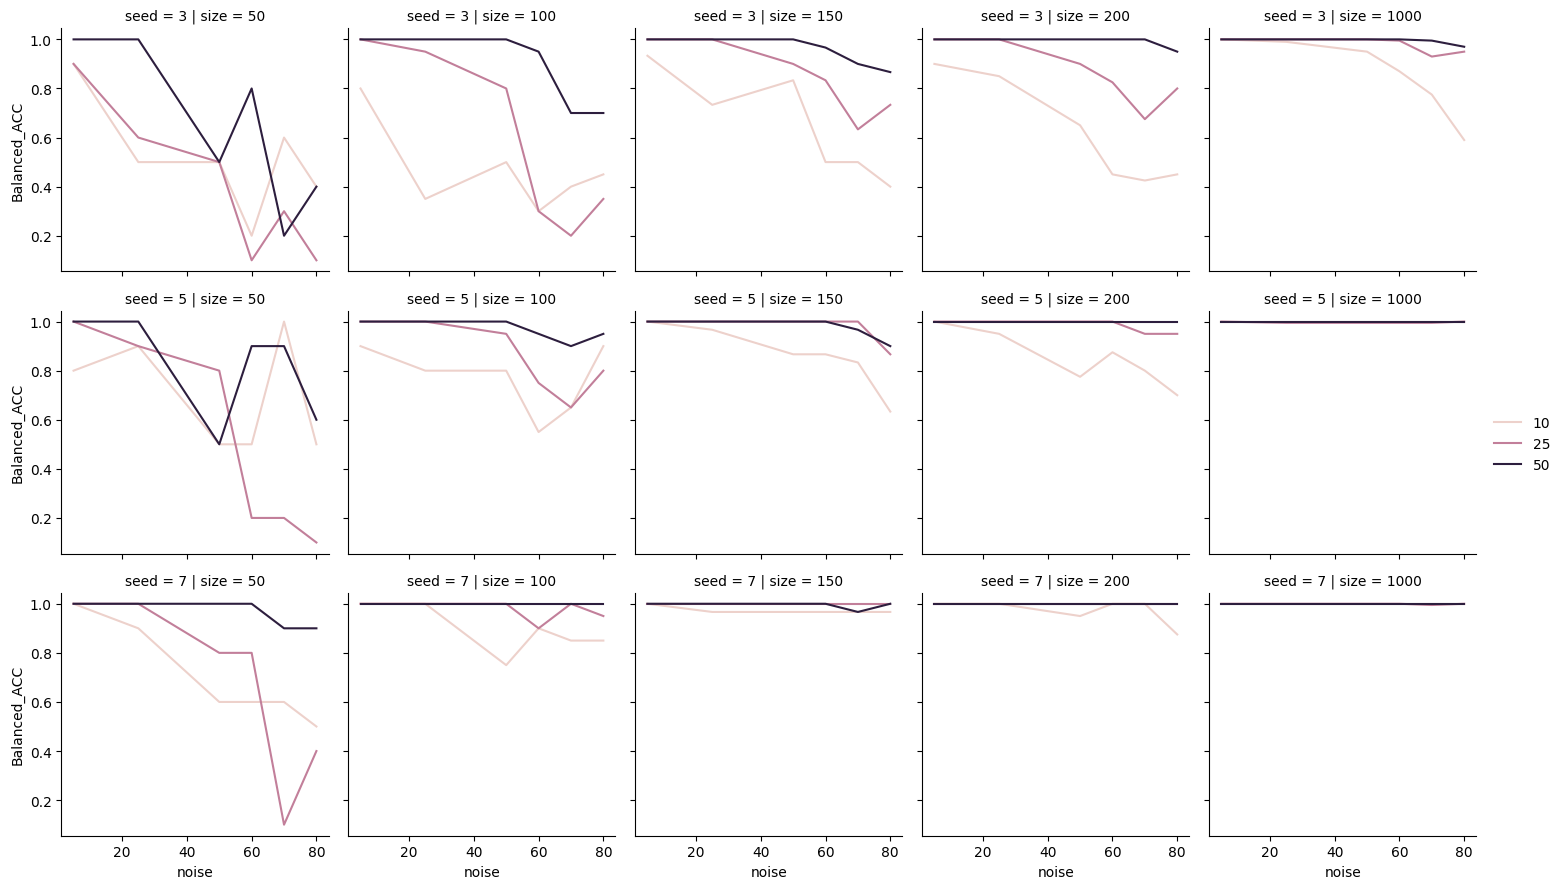

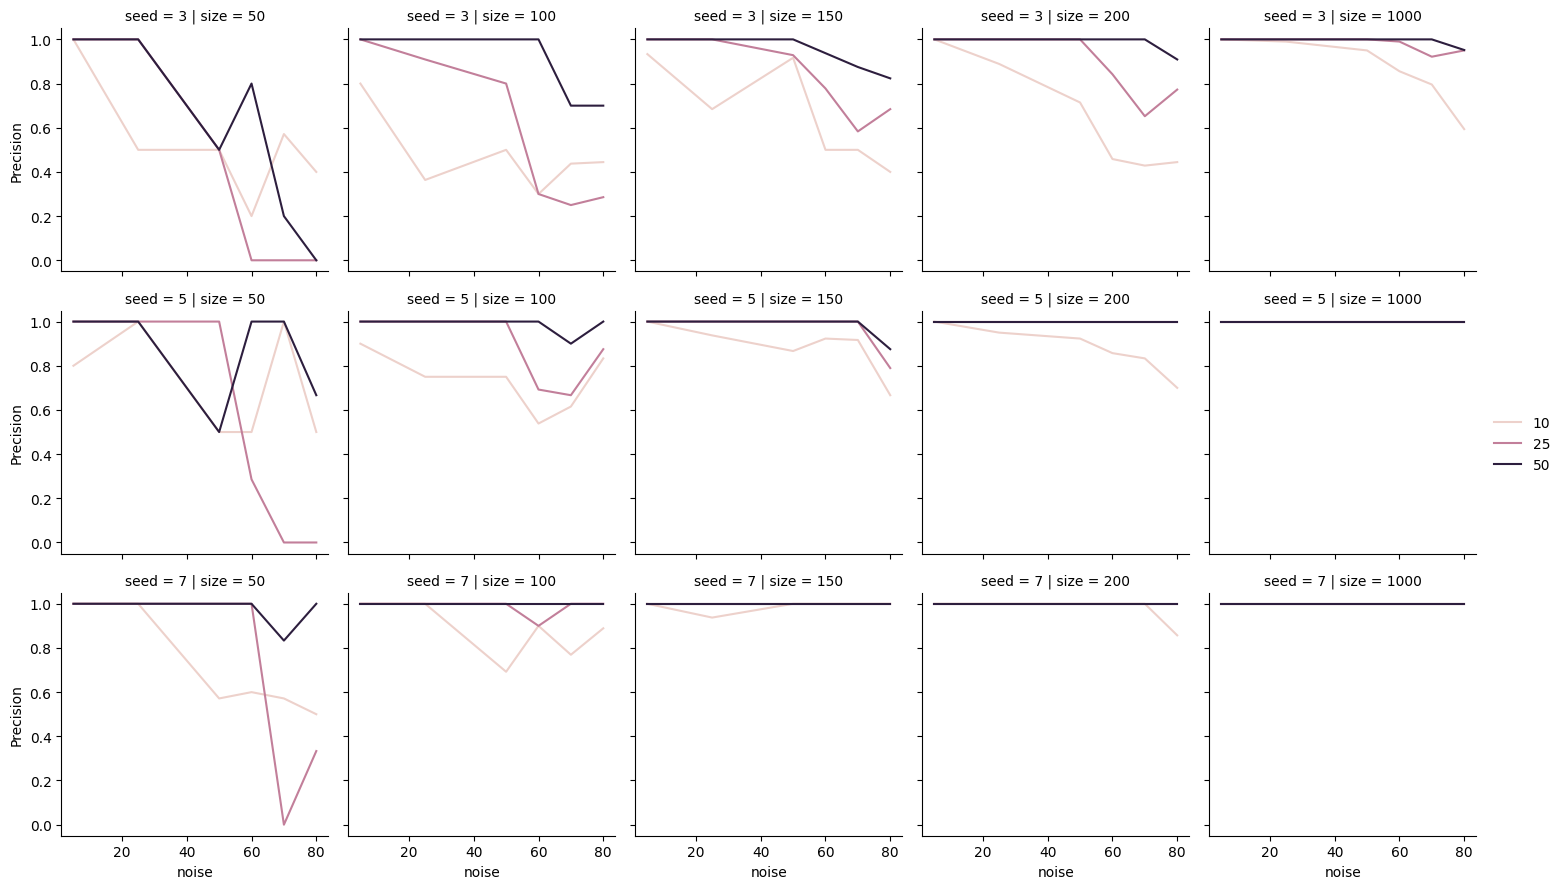

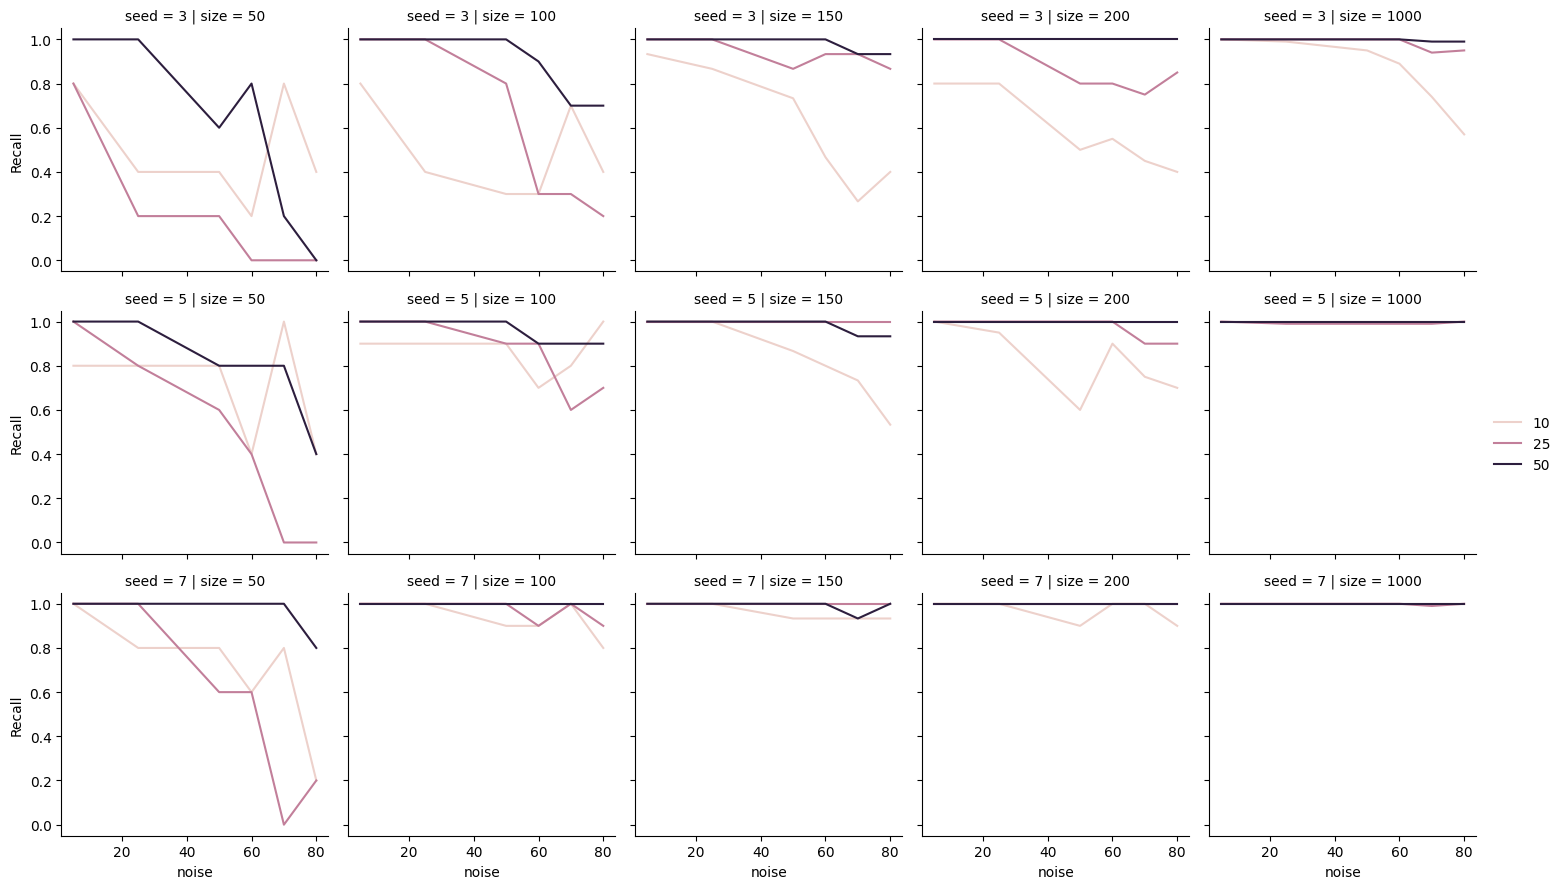

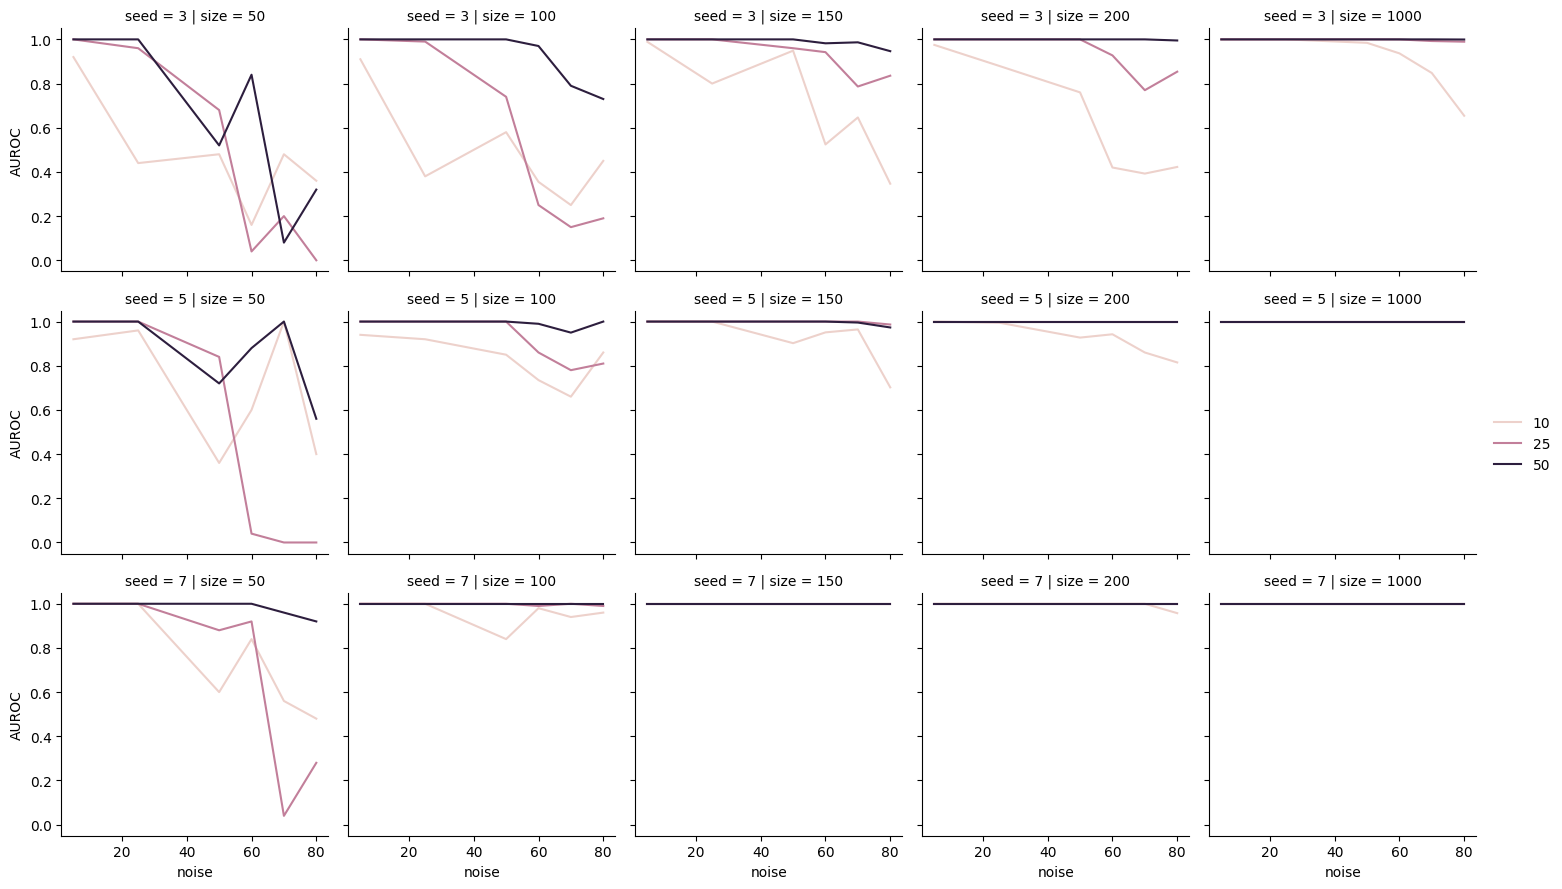

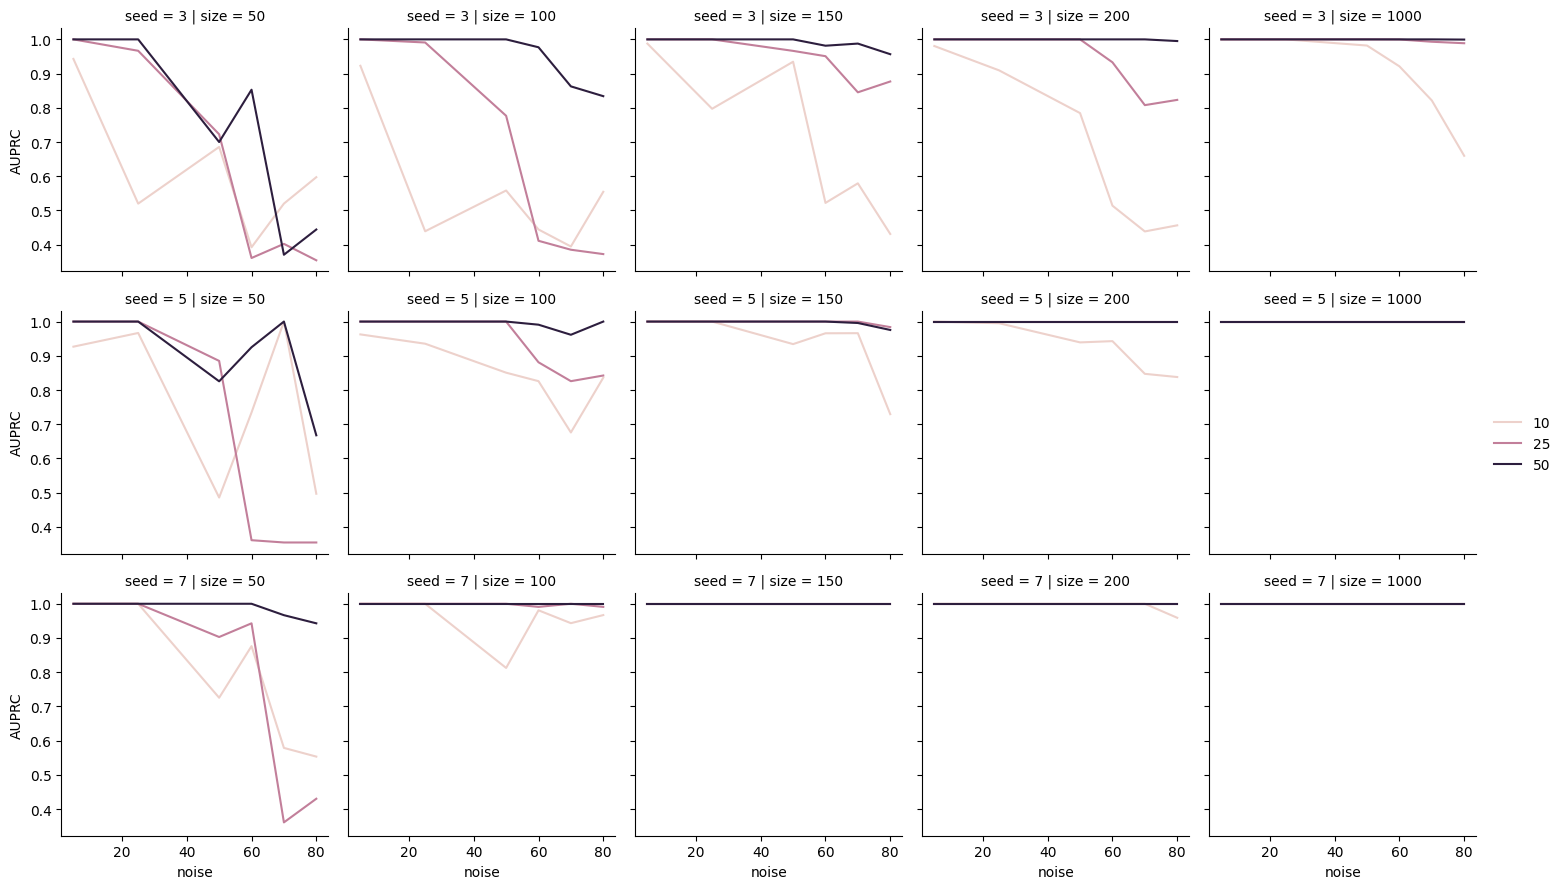

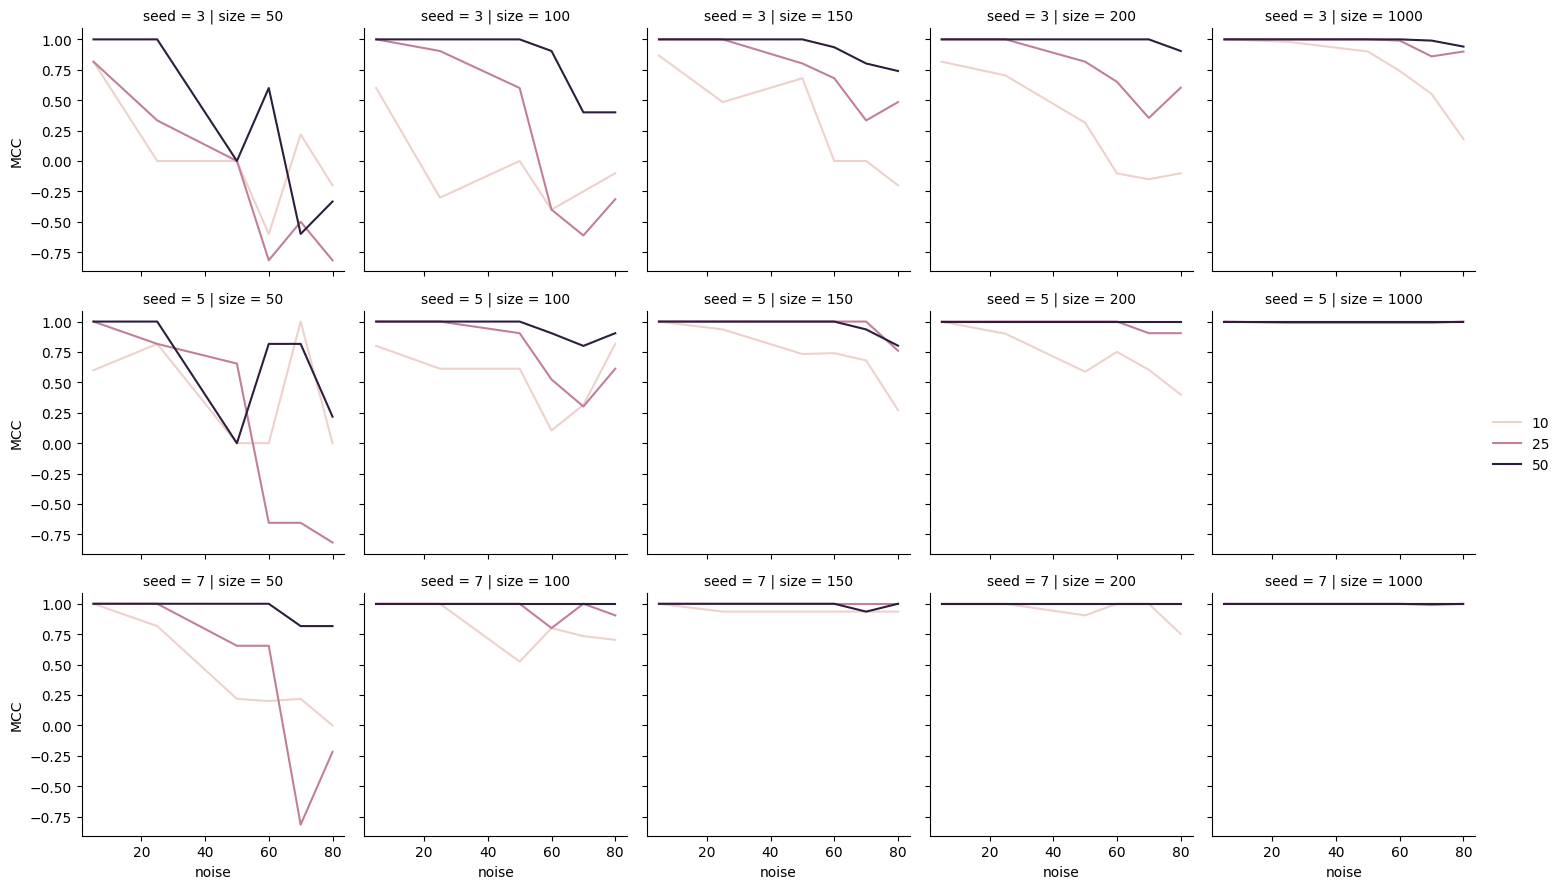

In [8]:
for metric in ['ACC', 'Balanced_ACC', 'Precision', 'Recall', 'AUROC', 'AUPRC', 'MCC']:
    g = sns.FacetGrid(metrics_df, col="size", row="seed")

    g.map_dataframe(
        sns.lineplot,
        x="noise",
        y=metric,
        hue="freq"
    )

    g.add_legend()